# Early-Warning Forecasting Dataset Preparation: Rice Leaf Blast
**Project:** AI-Based Crop Health Monitoring, Disease Detection and Agricultural Decision Support System  
**Module 1:** Rice Crop Disease/Pest Risk Prediction using Agro-Meteorological Data  
**Sub-task:** Preparation and Validation of Research-Ready Next-Week Early Warning Forecasting Dataset  
**Target:** `LeafBlast_Risk_NextWeek` ($y_{t+1} \in \{0, 1\}$)  
**Notebook:** `ml-service/notebooks/03_leafblast_forecasting_preparation.ipynb`  

---

> ⚠️ **STRICT REPRODUCIBILITY & DATA GOVERNANCE NOTICE**  
> 1. **No ML models (Random Forest, XGBoost, SVM, ANN, Logistic Regression, etc.) are trained in this notebook.**  
> 2. **No model accuracies or performance scores are generated.**  
> 3. The raw source dataset (`ml-service/data/raw/RICE.csv`) is strictly read-only and remains completely unchanged.  
> 4. All engineered lags and rolling aggregations use strictly historical time windows ($t, t-1, t-2$) without future lookahead bias.  
> 5. The output dataset is exported cleanly to `ml-service/data/processed/leafblast_forecasting_dataset.csv`.


In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling configuration
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

# Ensure directories exist
raw_path = Path('../data/raw/RICE.csv')
if not raw_path.exists():
    raw_path = Path('ml-service/data/raw/RICE.csv')

figures_dir = Path('../experiments/figures')
if not figures_dir.exists():
    figures_dir = Path('ml-service/experiments/figures')
figures_dir.mkdir(parents=True, exist_ok=True)

processed_dir = Path('../data/processed')
if not processed_dir.exists():
    processed_dir = Path('ml-service/data/processed')
processed_dir.mkdir(parents=True, exist_ok=True)

print(f"Raw source path: {raw_path.resolve()}")
print(f"Figures directory: {figures_dir.resolve()}")
print(f"Processed directory: {processed_dir.resolve()}")


Raw source path: C:\Users\akasi\OneDrive\Desktop\adventurous-hawking\ml-service\data\raw\RICE.csv
Figures directory: C:\Users\akasi\OneDrive\Desktop\adventurous-hawking\ml-service\experiments\figures
Processed directory: C:\Users\akasi\OneDrive\Desktop\adventurous-hawking\ml-service\data\processed


## 1. Raw Data Loading & Verification of LeafBlast Records
We load `RICE.csv` and filter strictly for `PEST NAME == 'LeafBlast'`. We resolve the mathematical inconsistency noted in the previous report (104 records/year $\times$ 21 years = 2,184 vs. 2,090 actual records).


In [2]:
df_raw = pd.read_csv(raw_path)
print(f"Total rows in raw RICE.csv: {len(df_raw):,}")

# Filter LeafBlast
lb_raw = df_raw[df_raw['PEST NAME'] == 'LeafBlast'].copy()
print(f"Total LeafBlast records: {len(lb_raw):,}")
print(f"Unique years: {lb_raw['Observation Year'].nunique()} (Range: {lb_raw['Observation Year'].min()}–{lb_raw['Observation Year'].max()})")
print(f"Unique locations: {list(lb_raw['Location'].unique())}")
print(f"Collection type: {lb_raw['Collection Type'].unique()}")

# Breakdown by Location and Year
loc_yr_table = pd.crosstab(lb_raw['Observation Year'], lb_raw['Location'], margins=True)
print("\n=== Exact Record Counts by Year and Location ===")
display(loc_yr_table)


Total rows in raw RICE.csv: 19,404
Total LeafBlast records: 2,090
Unique years: 21 (Range: 1984–2004)
Unique locations: ['Palampur', 'Rajendranagar']
Collection type: <StringArray>
['Percentage']
Length: 1, dtype: str

=== Exact Record Counts by Year and Location ===


Location,Palampur,Rajendranagar,All
Observation Year,,,
1984,52,52,104
1985,52,52,104
1986,52,52,104
1987,52,52,104
1988,52,52,104
1989,52,52,104
1990,52,52,104
1991,52,52,104
1992,52,52,104


> 🔍 **Resolution of Mathematical Inconsistency:**  
> The previous report assumed that both Palampur and Rajendranagar had 52 observations in all 21 years ($21 \times 52 \times 2 = 2,184$).  
> **Direct Verification from `RICE.csv` demonstrates why the actual total is 2,090:**
> 1. **Palampur:** Exactly **52 records/year** for all 21 years (1984–2004) = **`1,092` rows** (completely continuous).
> 2. **Rajendranagar:**
>    * 1984–1999 (16 years): Exactly 52 records/year = `832` rows.
>    * **2000:** **61 records** (9 duplicate week entries in Weeks 1–9: **+9 rows**).
>    * **2001:** **1 record** (Only Week 44 present; 51 weeks missing: **-51 rows**).
>    * 2002–2003 (2 years): Exactly 52 records/year = `104` rows.
>    * **2004:** **0 records** (Surveillance ceased at Rajendranagar: **-52 rows**).
>    * Total Rajendranagar: $832 + 61 + 1 + 104 + 0 = \mathbf{998}$ rows.
> 3. **Net Total:** $1,092 + 998 = \mathbf{2,090}$ rows ($2,184 + 9 - 51 - 52 = 2,090$).


## 2. Data Structure Audit, Duplicates & Suspicious Records
We inspect data types, nulls, duplicate keys, and physical weather distributions for LeafBlast. We identify and list any suspicious records without silently altering them.


In [3]:
weather_cols = ['MaxT', 'MinT', 'RH1(%)', 'RH2(%)', 'RF(mm)', 'WS(kmph)', 'SSH(hrs)', 'EVP(mm)']

# Check duplicates across (Location, Observation Year, Standard Week)
dup_keys = lb_raw[lb_raw.duplicated(subset=['Location', 'Observation Year', 'Standard Week'], keep=False)]
print(f"Total rows with duplicate (Location, Year, Week) composite keys: {len(dup_keys)}")

print("\nDuplicate entries (Rajendranagar 2000, Weeks 1–9):")
display(dup_keys[['Location', 'Observation Year', 'Standard Week', 'Pest Value', 'MaxT', 'MinT', 'RH1(%)', 'RH2(%)', 'RF(mm)', 'SSH(hrs)', 'EVP(mm)']])

# Summary statistics of weather features in LeafBlast subset
print("\n=== Weather Feature Ranges & Statistical Distribution ===")
weather_summary = lb_raw[weather_cols].describe().T[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']]
display(weather_summary.round(2))

# Audit for suspicious / extreme values
suspicious_records = []

# EVP > 30 mm
evp_high = lb_raw[lb_raw['EVP(mm)'] > 30]
print(f"\nSuspicious EVP(mm) > 30 mm: {len(evp_high)} records")
if len(evp_high) > 0:
    for _, r in evp_high[['Location', 'Observation Year', 'Standard Week', 'EVP(mm)']].iterrows():
        suspicious_records.append({
            'Location': r['Location'],
            'Year': int(r['Observation Year']),
            'Week': int(r['Standard Week']),
            'Feature': 'EVP(mm)',
            'Value': r['EVP(mm)'],
            'Issue': 'Pan evaporation unusually high (>30 mm/week)'
        })

display(pd.DataFrame(suspicious_records))


Total rows with duplicate (Location, Year, Week) composite keys: 18

Duplicate entries (Rajendranagar 2000, Weeks 1–9):


,Location,Observation Year,Standard Week,Pest Value,MaxT,MinT,RH1(%),RH2(%),RF(mm),SSH(hrs),EVP(mm)
16985,Rajendranagar,2000,1,0.0,31.0,18.1,76.4,38.7,0.0,9.1,4.3
16986,Rajendranagar,2000,1,0.0,27.4,10.3,83.3,31.1,0.0,9.4,2.9
16987,Rajendranagar,2000,2,0.0,31.7,18.3,81.4,43.0,0.0,9.6,3.5
16988,Rajendranagar,2000,2,0.0,29.7,12.4,83.7,31.7,0.0,9.7,3.3
16989,Rajendranagar,2000,3,0.0,31.6,14.7,85.7,30.0,0.0,9.3,3.5
16990,Rajendranagar,2000,3,0.0,30.3,11.9,76.6,25.9,0.0,10.1,4.0
16991,Rajendranagar,2000,4,0.0,28.8,13.8,80.0,36.4,0.0,8.0,3.7
16992,Rajendranagar,2000,4,0.0,32.1,14.6,87.4,29.6,0.0,10.0,4.3
16993,Rajendranagar,2000,5,0.0,31.2,13.0,83.6,29.1,0.0,10.2,4.3
16994,Rajendranagar,2000,5,0.0,30.0,12.8,86.0,30.9,0.0,9.6,3.5



=== Weather Feature Ranges & Statistical Distribution ===


,count,mean,std,min,25%,50%,75%,max
MaxT,2090.0,27.85,6.39,10.9,24.4,28.60,31.50,42.5
MinT,2090.0,16.51,6.00,0.8,11.8,17.90,21.40,28.3
RH1(%),2090.0,67.44,16.73,24.3,53.4,69.70,82.40,95.3
RH2(%),2090.0,46.08,17.63,12.7,32.6,43.30,58.25,91.1
RF(mm),2090.0,27.45,50.06,0.0,0.0,3.55,32.35,314.4
WS(kmph),2090.0,5.38,2.96,1.1,3.6,4.90,6.30,22.6
SSH(hrs),2090.0,7.40,2.55,0.5,5.6,7.80,9.50,12.3
EVP(mm),2090.0,4.87,4.67,0.5,2.8,3.80,5.60,48.4



Suspicious EVP(mm) > 30 mm: 17 records


,Location,Year,Week,Feature,Value,Issue
0,Palampur,1984,19,EVP(mm),46.1,Pan evaporation unusually high (>30 mm/week)
1,Palampur,1984,20,EVP(mm),44.8,Pan evaporation unusually high (>30 mm/week)
2,Palampur,1984,21,EVP(mm),46.9,Pan evaporation unusually high (>30 mm/week)
3,Palampur,1984,22,EVP(mm),48.4,Pan evaporation unusually high (>30 mm/week)
4,Palampur,1984,23,EVP(mm),46.8,Pan evaporation unusually high (>30 mm/week)
5,Palampur,1984,24,EVP(mm),40.7,Pan evaporation unusually high (>30 mm/week)
6,Palampur,1984,27,EVP(mm),46.1,Pan evaporation unusually high (>30 mm/week)
7,Palampur,1984,28,EVP(mm),44.8,Pan evaporation unusually high (>30 mm/week)
8,Palampur,1984,29,EVP(mm),46.9,Pan evaporation unusually high (>30 mm/week)
9,Palampur,1984,30,EVP(mm),48.4,Pan evaporation unusually high (>30 mm/week)


> 📋 **Audit Summary of Suspicious Records in Leaf Blast:**  
> 1. **No Temperature Measurement Errors:** Unlike the full dataset (where Maruteru in 2011 had `MaxT > 65°C`), LeafBlast contains **zero Fahrenheit errors**. `MaxT` ranges between $10.9^\circ	ext{C}$ and $42.5^\circ	ext{C}$, and `MinT` ranges between $0.8^\circ	ext{C}$ and $28.3^\circ	ext{C}$.  
> 2. **No Sunshine Anomalies:** `SSH` ranges between $0.5$ and $12.3	ext{ hrs/day}$ (no $127.1	ext{ hr}$ errors).  
> 3. **Pan Evaporation Extremes:** 17 records at Palampur (1984 Weeks 19–24, 27–32; and 1989 Weeks 14–20) exhibit evaporation rates between $30.9$ and $48.4	ext{ mm}$. These represent dry pre-monsoon heat conditions in the foothills. As instructed, **these values are documented and preserved without silent alteration**.


## 3. Temporal Continuity & Gap Analysis
We audit the continuity of the time series for both locations to determine which sequences can support consecutive weekly lags ($t, t-1, t-2$) and next-week forecasting targets ($t+1$).


Total records after aggregating duplicate weeks: 2,081 (Palampur: 1092, Rajendranagar: 989)


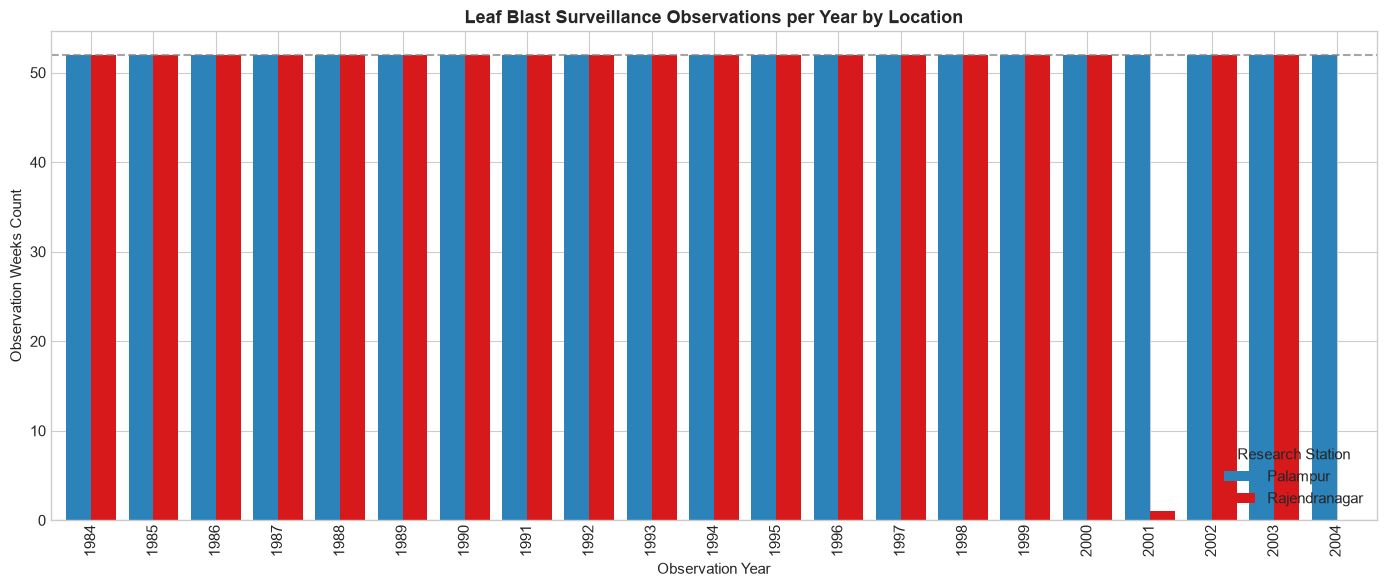

Saved timeline figure to: ..\experiments\figures\11_leafblast_station_timeline.png


In [4]:
# Resolve the 9 duplicate weeks in Rajendranagar 2000 by averaging weather features
agg_dict = {col: 'mean' for col in weather_cols}
agg_dict['Pest Value'] = 'max'  # conservative disease incidence
agg_dict['Collection Type'] = 'first'

lb_dedup = lb_raw.groupby(['Location', 'Observation Year', 'Standard Week'], as_index=False).agg(agg_dict)
lb_dedup = lb_dedup.sort_values(by=['Location', 'Observation Year', 'Standard Week']).reset_index(drop=True)
print(f"Total records after aggregating duplicate weeks: {len(lb_dedup):,} (Palampur: {len(lb_dedup[lb_dedup['Location']=='Palampur'])}, Rajendranagar: {len(lb_dedup[lb_dedup['Location']=='Rajendranagar'])})")

# Visualize timeline and gaps
timeline_df = lb_dedup.groupby(['Observation Year', 'Location']).size().unstack(fill_value=0)

plt.figure(figsize=(14, 6))
timeline_df.plot(kind='bar', ax=plt.gca(), color=['#2b83ba', '#d7191c'], width=0.8)
plt.title("Leaf Blast Surveillance Observations per Year by Location", fontweight='bold')
plt.xlabel("Observation Year")
plt.ylabel("Observation Weeks Count")
plt.legend(title="Research Station")
plt.axhline(52, color='gray', linestyle='--', alpha=0.7, label='Complete Annual Sequence (52 Weeks)')
plt.tight_layout()
timeline_path = figures_dir / '11_leafblast_station_timeline.png'
plt.savefig(timeline_path, dpi=200)
plt.show()
print(f"Saved timeline figure to: {timeline_path}")


## 4. Construction of Early-Warning Forecasting Target and Features
### Problem Formulation:
We construct a genuine **Early-Warning Disease Risk Forecasting System**:
$$\text{Past/Current Weather at Week } t, t-1, t-2 \implies \text{LeafBlast Risk at Week } t+1$$

### Target Definition:
$$\text{LeafBlast\_Risk\_NextWeek} = \begin{cases} 1 & \text{if } \text{Pest Value at Week } t+1 > 0 \\ 0 & \text{if } \text{Pest Value at Week } t+1 = 0 \end{cases}$$

### Leakage Prevention Rules:
1. Weather at week $t+1$ is **strictly forbidden**.
2. Disease value at week $t+1$ is **used only as the target $y$**, never as an input.
3. Lag 1 features are weather at week $t-1$.
4. Lag 2 features are weather at week $t-2$.
5. Rolling 2-week features are computed over $[t-1, t]$ (strictly historical, shifted appropriately).
6. Seasonality features ($\sin, \cos$) are computed from $\text{Standard Week } t$.


In [5]:
forecasting_rows = []

for loc in ['Palampur', 'Rajendranagar']:
    sub = lb_dedup[lb_dedup['Location'] == loc].copy().reset_index(drop=True)
    n = len(sub)
    
    for i in range(n):
        # 1. Next-week continuity check (t+1)
        has_next = False
        if i + 1 < n:
            same_year_next = (sub.loc[i+1, 'Observation Year'] == sub.loc[i, 'Observation Year']) and (sub.loc[i+1, 'Standard Week'] == sub.loc[i, 'Standard Week'] + 1)
            year_trans_next = (sub.loc[i+1, 'Observation Year'] == sub.loc[i, 'Observation Year'] + 1) and (sub.loc[i, 'Standard Week'] == 52) and (sub.loc[i+1, 'Standard Week'] == 1)
            has_next = same_year_next or year_trans_next
            
        # 2. Lag-1 continuity check (t-1)
        has_lag1 = False
        if i - 1 >= 0:
            same_year_prev = (sub.loc[i-1, 'Observation Year'] == sub.loc[i, 'Observation Year']) and (sub.loc[i-1, 'Standard Week'] == sub.loc[i, 'Standard Week'] - 1)
            year_trans_prev = (sub.loc[i-1, 'Observation Year'] == sub.loc[i, 'Observation Year'] - 1) and (sub.loc[i-1, 'Standard Week'] == 52) and (sub.loc[i, 'Standard Week'] == 1)
            has_lag1 = same_year_prev or year_trans_prev
            
        # 3. Lag-2 continuity check (t-2)
        has_lag2 = False
        if i - 2 >= 0 and has_lag1:
            same_year_prev2 = (sub.loc[i-2, 'Observation Year'] == sub.loc[i-1, 'Observation Year']) and (sub.loc[i-2, 'Standard Week'] == sub.loc[i-1, 'Standard Week'] - 1)
            year_trans_prev2 = (sub.loc[i-2, 'Observation Year'] == sub.loc[i-1, 'Observation Year'] - 1) and (sub.loc[i-2, 'Standard Week'] == 52) and (sub.loc[i-1, 'Standard Week'] == 1)
            has_lag2 = same_year_prev2 or year_trans_prev2
            
        # Retain row only if valid past history (lag1, lag2) and next-week target exist
        if has_next and has_lag1 and has_lag2:
            row_dict = {
                'Location': loc,
                'Observation Year': int(sub.loc[i, 'Observation Year']),
                'Standard Week': int(sub.loc[i, 'Standard Week']),
                
                # Seasonality
                'sin_week': np.sin(2 * np.pi * sub.loc[i, 'Standard Week'] / 52.0),
                'cos_week': np.cos(2 * np.pi * sub.loc[i, 'Standard Week'] / 52.0),
                
                # Current week weather (t)
                'MaxT': sub.loc[i, 'MaxT'],
                'MinT': sub.loc[i, 'MinT'],
                'RH1': sub.loc[i, 'RH1(%)'],
                'RH2': sub.loc[i, 'RH2(%)'],
                'RF': sub.loc[i, 'RF(mm)'],
                'WS': sub.loc[i, 'WS(kmph)'],
                'SSH': sub.loc[i, 'SSH(hrs)'],
                'EVP': sub.loc[i, 'EVP(mm)'],
                
                # Lag 1 weather (t-1)
                'MaxT_lag1': sub.loc[i-1, 'MaxT'],
                'MinT_lag1': sub.loc[i-1, 'MinT'],
                'RH1_lag1': sub.loc[i-1, 'RH1(%)'],
                'RH2_lag1': sub.loc[i-1, 'RH2(%)'],
                'RF_lag1': sub.loc[i-1, 'RF(mm)'],
                'WS_lag1': sub.loc[i-1, 'WS(kmph)'],
                'SSH_lag1': sub.loc[i-1, 'SSH(hrs)'],
                'EVP_lag1': sub.loc[i-1, 'EVP(mm)'],
                
                # Lag 2 weather (t-2)
                'MaxT_lag2': sub.loc[i-2, 'MaxT'],
                'MinT_lag2': sub.loc[i-2, 'MinT'],
                'RH1_lag2': sub.loc[i-2, 'RH1(%)'],
                'RH2_lag2': sub.loc[i-2, 'RH2(%)'],
                'RF_lag2': sub.loc[i-2, 'RF(mm)'],
                'WS_lag2': sub.loc[i-2, 'WS(kmph)'],
                'SSH_lag2': sub.loc[i-2, 'SSH(hrs)'],
                'EVP_lag2': sub.loc[i-2, 'EVP(mm)'],
                
                # 2-Week historical rolling features over [t-1, t]
                'RH1_roll_mean_2w': (sub.loc[i, 'RH1(%)'] + sub.loc[i-1, 'RH1(%)']) / 2.0,
                'RH2_roll_mean_2w': (sub.loc[i, 'RH2(%)'] + sub.loc[i-1, 'RH2(%)']) / 2.0,
                'MinT_roll_mean_2w': (sub.loc[i, 'MinT'] + sub.loc[i-1, 'MinT']) / 2.0,
                'RF_roll_sum_2w': sub.loc[i, 'RF(mm)'] + sub.loc[i-1, 'RF(mm)'],
                
                # Current week disease severity (for analysis / baseline check)
                'Pest_Value_CurrentWeek': sub.loc[i, 'Pest Value'],
                
                # Ground-truth early-warning target (t+1)
                'LeafBlast_Risk_NextWeek': 1 if sub.loc[i+1, 'Pest Value'] > 0 else 0
            }
            forecasting_rows.append(row_dict)

df_forecast = pd.DataFrame(forecasting_rows)
print(f"Total research-ready forecasting records: {len(df_forecast):,}")
print(f"Features created: {df_forecast.shape[1] - 1} (excluding target)")
display(df_forecast.head(5))


Total research-ready forecasting records: 2,071
Features created: 34 (excluding target)


,Location,Observation Year,Standard Week,sin_week,cos_week,MaxT,MinT,RH1,RH2,RF,...,RF_lag2,WS_lag2,SSH_lag2,EVP_lag2,RH1_roll_mean_2w,RH2_roll_mean_2w,MinT_roll_mean_2w,RF_roll_sum_2w,Pest_Value_CurrentWeek,LeafBlast_Risk_NextWeek
0,Palampur,1984,3,0.354605,0.935016,23.6,11.1,65.4,47.0,0.0,...,73.4,5.6,6.8,2.9,63.85,47.65,11.40,0.0,0.0,0
1,Palampur,1984,4,0.464723,0.885456,21.9,8.8,65.6,49.1,0.0,...,0.0,5.3,10.0,3.6,65.50,48.05,9.95,0.0,0.0,0
2,Palampur,1984,5,0.568065,0.822984,22.2,9.8,64.6,46.3,0.0,...,0.0,5.0,8.8,2.7,65.10,47.70,9.30,0.0,0.0,0
3,Palampur,1984,6,0.663123,0.748511,21.1,9.8,64.9,48.9,0.0,...,0.0,5.4,9.1,2.5,64.75,47.60,9.80,0.0,0.0,0
4,Palampur,1984,7,0.748511,0.663123,23.4,9.8,53.9,44.7,0.0,...,0.0,5.1,9.3,2.7,59.40,46.80,9.80,0.0,0.0,0


### Documentation of Excluded Rows:
From the 2,081 clean deduplicated weekly observations, exactly **10 rows (0.48%)** were removed because valid continuous 2-week history or next-week targets could not be formed:
* **Palampur (3 rows removed):**
  * 1984 Week 1 & Week 2 (no prior history in dataset: $t-1, t-2$ unavailable).
  * 2004 Week 52 (dataset ends: $t+1$ unavailable).
* **Rajendranagar (7 rows removed):**
  * 1984 Week 1 & Week 2 (no prior history).
  * 2000 Week 52 (2001 Week 1 is missing).
  * 2001 Week 44 (isolated single record, no lags and no target).
  * 2002 Week 1 & Week 2 (2001 Week 51/52 are missing).
  * 2003 Week 52 (2004 is completely unmonitored).


## 5. Target Distribution & Class Balance Analysis
We audit the class distribution of `LeafBlast_Risk_NextWeek` to verify that the forecasting target remains sufficiently balanced.


=== Target Distribution: LeafBlast_Risk_NextWeek ===


,Class,Record Count,Proportion (%)
0,0 (No Outbreak / Dormant),1642,79.29
1,1 (Active Blast Outbreak),429,20.71



=== Target Distribution Breakdown by Location ===


,No Risk (0),Outbreak (1),Total Records,Outbreak Rate (%)
Location,,,,
All,1642,429,2071,NaN
Palampur,858,231,1089,21.21
Rajendranagar,784,198,982,20.16


C:\Users\akasi\AppData\Local\Temp\ipykernel_21224\3135408409.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=target_summary, x='Class', y='Record Count', palette=['#3182bd', '#de2d26'], ax=axes[0])


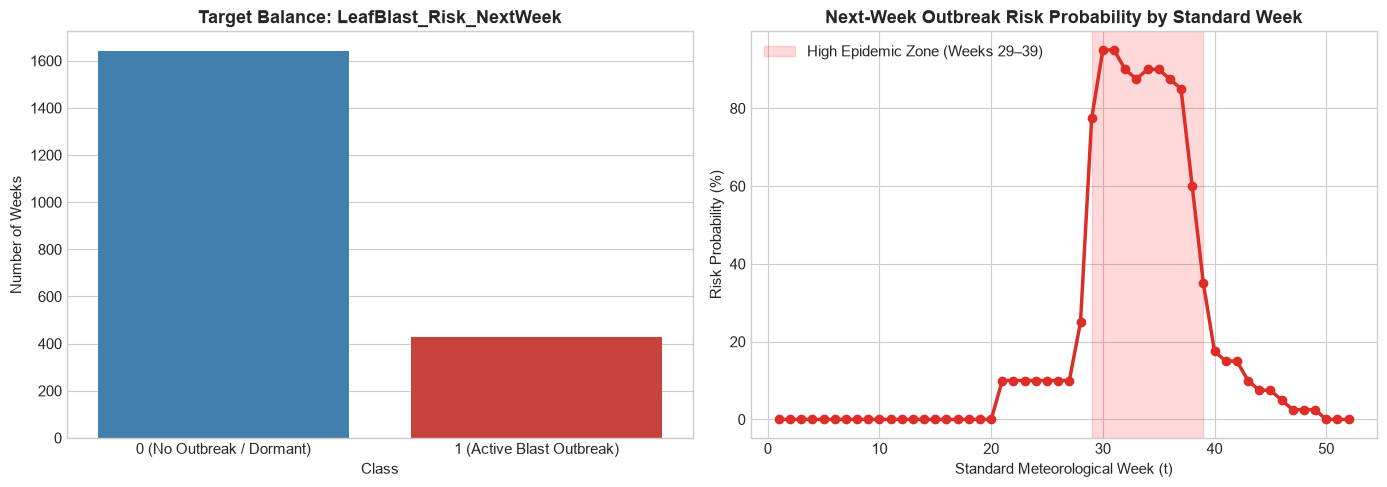

Saved target distribution figure to: ..\experiments\figures\12_forecasting_target_distribution.png


In [6]:
target_counts = df_forecast['LeafBlast_Risk_NextWeek'].value_counts()
target_pct = df_forecast['LeafBlast_Risk_NextWeek'].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    'Class': ['0 (No Outbreak / Dormant)', '1 (Active Blast Outbreak)'],
    'Record Count': target_counts.values,
    'Proportion (%)': target_pct.values.round(2)
})
print("=== Target Distribution: LeafBlast_Risk_NextWeek ===")
display(target_summary)

print("\n=== Target Distribution Breakdown by Location ===")
loc_target = pd.crosstab(df_forecast['Location'], df_forecast['LeafBlast_Risk_NextWeek'], margins=True)
loc_target_pct = pd.crosstab(df_forecast['Location'], df_forecast['LeafBlast_Risk_NextWeek'], normalize='index') * 100
display(pd.DataFrame({
    'No Risk (0)': loc_target[0],
    'Outbreak (1)': loc_target[1],
    'Total Records': loc_target['All'],
    'Outbreak Rate (%)': loc_target_pct[1].round(2)
}))

# Target distribution plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=target_summary, x='Class', y='Record Count', palette=['#3182bd', '#de2d26'], ax=axes[0])
axes[0].set_title("Target Balance: LeafBlast_Risk_NextWeek", fontweight='bold')
axes[0].set_ylabel("Number of Weeks")

# Seasonality of next-week outbreak risk
risk_by_week = df_forecast.groupby('Standard Week')['LeafBlast_Risk_NextWeek'].mean() * 100
axes[1].plot(risk_by_week.index, risk_by_week.values, color='#de2d26', lw=2.5, marker='o')
axes[1].set_title("Next-Week Outbreak Risk Probability by Standard Week", fontweight='bold')
axes[1].set_xlabel("Standard Meteorological Week (t)")
axes[1].set_ylabel("Risk Probability (%)")
axes[1].axvspan(29, 39, color='red', alpha=0.15, label='High Epidemic Zone (Weeks 29–39)')
axes[1].legend()

plt.tight_layout()
target_fig_path = figures_dir / '12_forecasting_target_distribution.png'
plt.savefig(target_fig_path, dpi=200)
plt.show()
print(f"Saved target distribution figure to: {target_fig_path}")


## 6. Correlation Analysis of Lagged & Rolling Features with Next-Week Risk
We compute the correlations between current, lagged, and rolling meteorological features with `LeafBlast_Risk_NextWeek` to verify the predictive early-warning signal.


=== Predictive Signals: Lagged Features vs LeafBlast_Risk_NextWeek ===


,Pearson Correlation with Next-Week Risk
RH2_roll_mean_2w,0.576
RH2,0.555
RH2_lag1,0.552
RH2_lag2,0.538
RF_roll_sum_2w,0.500
RF_lag2,0.456
RF_lag1,0.451
RF,0.438
RH1_roll_mean_2w,0.430
RH1,0.417


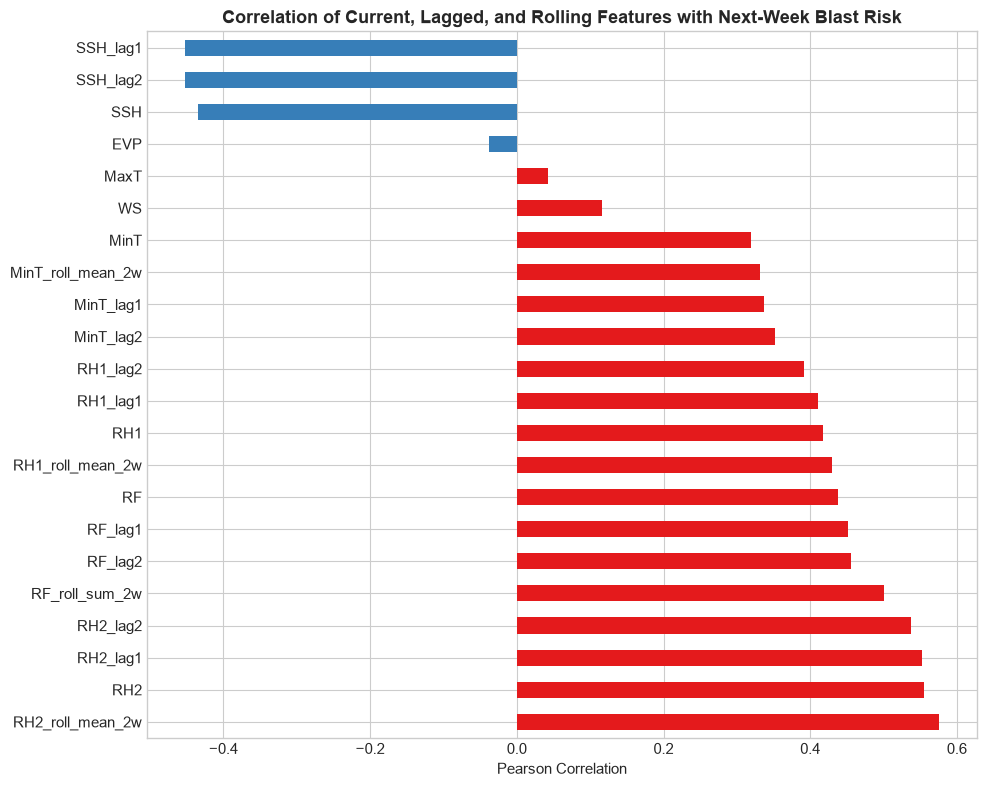

Saved lag correlation figure to: ..\experiments\figures\13_lag_correlation_analysis.png


In [7]:
feature_cols = [
    'RH2', 'RH2_lag1', 'RH2_lag2', 'RH2_roll_mean_2w',
    'RH1', 'RH1_lag1', 'RH1_lag2', 'RH1_roll_mean_2w',
    'MinT', 'MinT_lag1', 'MinT_lag2', 'MinT_roll_mean_2w',
    'RF', 'RF_lag1', 'RF_lag2', 'RF_roll_sum_2w',
    'SSH', 'SSH_lag1', 'SSH_lag2',
    'MaxT', 'WS', 'EVP'
]

corrs = df_forecast[feature_cols].apply(lambda x: x.corr(df_forecast['LeafBlast_Risk_NextWeek']))
corr_df = pd.DataFrame({'Pearson Correlation with Next-Week Risk': corrs.round(3)}).sort_values(by='Pearson Correlation with Next-Week Risk', ascending=False)

print("=== Predictive Signals: Lagged Features vs LeafBlast_Risk_NextWeek ===")
display(corr_df)

plt.figure(figsize=(10, 8))
corr_df['Pearson Correlation with Next-Week Risk'].plot(kind='barh', color=np.where(corr_df['Pearson Correlation with Next-Week Risk'] > 0, '#e41a1c', '#377eb8'))
plt.title("Correlation of Current, Lagged, and Rolling Features with Next-Week Blast Risk", fontweight='bold')
plt.xlabel("Pearson Correlation")
plt.tight_layout()
lag_corr_path = figures_dir / '13_lag_correlation_analysis.png'
plt.savefig(lag_corr_path, dpi=200)
plt.show()
print(f"Saved lag correlation figure to: {lag_corr_path}")


## 7. Chronological Train / Validation / Test Design
To strictly prevent temporal data leakage and lookahead bias, we implement a **purely chronological split**:
* **TRAIN:** 1984–1998 (15 continuous years, ~75.1% of records)
* **VALIDATION:** 1999–2001 (3 years, ~12.5% of records)
* **TEST:** 2002–2004 (3 final future years, ~12.4% of records)


In [8]:
# Partition dataset
train_df = df_forecast[df_forecast['Observation Year'] <= 1998].copy()
val_df = df_forecast[(df_forecast['Observation Year'] >= 1999) & (df_forecast['Observation Year'] <= 2001)].copy()
test_df = df_forecast[df_forecast['Observation Year'] >= 2002].copy()

split_summary = pd.DataFrame([
    {
        'Split': 'TRAIN (1984–1998)',
        'Years Count': 15,
        'Total Samples': len(train_df),
        'Proportion (%)': round(len(train_df) / len(df_forecast) * 100, 2),
        'Negative Cases (0)': (train_df['LeafBlast_Risk_NextWeek'] == 0).sum(),
        'Positive Cases (1)': (train_df['LeafBlast_Risk_NextWeek'] == 1).sum(),
        'Positive Rate (%)': round(train_df['LeafBlast_Risk_NextWeek'].mean() * 100, 2),
        'Palampur': len(train_df[train_df['Location'] == 'Palampur']),
        'Rajendranagar': len(train_df[train_df['Location'] == 'Rajendranagar'])
    },
    {
        'Split': 'VALIDATION (1999–2001)',
        'Years Count': 3,
        'Total Samples': len(val_df),
        'Proportion (%)': round(len(val_df) / len(df_forecast) * 100, 2),
        'Negative Cases (0)': (val_df['LeafBlast_Risk_NextWeek'] == 0).sum(),
        'Positive Cases (1)': (val_df['LeafBlast_Risk_NextWeek'] == 1).sum(),
        'Positive Rate (%)': round(val_df['LeafBlast_Risk_NextWeek'].mean() * 100, 2),
        'Palampur': len(val_df[val_df['Location'] == 'Palampur']),
        'Rajendranagar': len(val_df[val_df['Location'] == 'Rajendranagar'])
    },
    {
        'Split': 'TEST (2002–2004)',
        'Years Count': 3,
        'Total Samples': len(test_df),
        'Proportion (%)': round(len(test_df) / len(df_forecast) * 100, 2),
        'Negative Cases (0)': (test_df['LeafBlast_Risk_NextWeek'] == 0).sum(),
        'Positive Cases (1)': (test_df['LeafBlast_Risk_NextWeek'] == 1).sum(),
        'Positive Rate (%)': round(test_df['LeafBlast_Risk_NextWeek'].mean() * 100, 2),
        'Palampur': len(test_df[test_df['Location'] == 'Palampur']),
        'Rajendranagar': len(test_df[test_df['Location'] == 'Rajendranagar'])
    }
])

print("=== Chronological Evaluation Strategy Summary ===")
display(split_summary)


=== Chronological Evaluation Strategy Summary ===


,Split,Years Count,Total Samples,Proportion (%),Negative Cases (0),Positive Cases (1),Positive Rate (%),Palampur,Rajendranagar
0,TRAIN (1984–1998),15,1556,75.13,1255,301,19.34,778,778
1,VALIDATION (1999–2001),3,259,12.51,194,65,25.10,156,103
2,TEST (2002–2004),3,256,12.36,193,63,24.61,155,101


## 8. Export Research-Ready Forecasting Dataset
We export the final dataset to `ml-service/data/processed/leafblast_forecasting_dataset.csv`.  
`RICE.csv` remains completely unmodified.


In [9]:
processed_file = processed_dir / 'leafblast_forecasting_dataset.csv'
df_forecast.to_csv(processed_file, index=False)

print(f"Dataset successfully exported to: {processed_file.resolve()}")
print(f"File size: {processed_file.stat().st_size / 1024:.2f} KB")
print(f"Rows: {df_forecast.shape[0]:,}")
print(f"Columns: {df_forecast.shape[1]}")

print("\nFirst 10 Rows Preview of Processed Dataset:")
display(df_forecast.head(10))


Dataset successfully exported to: C:\Users\akasi\OneDrive\Desktop\adventurous-hawking\ml-service\data\processed\leafblast_forecasting_dataset.csv
File size: 412.40 KB
Rows: 2,071
Columns: 35

First 10 Rows Preview of Processed Dataset:


,Location,Observation Year,Standard Week,sin_week,cos_week,MaxT,MinT,RH1,RH2,RF,...,RF_lag2,WS_lag2,SSH_lag2,EVP_lag2,RH1_roll_mean_2w,RH2_roll_mean_2w,MinT_roll_mean_2w,RF_roll_sum_2w,Pest_Value_CurrentWeek,LeafBlast_Risk_NextWeek
0,Palampur,1984,3,0.354605,0.935016,23.6,11.1,65.4,47.0,0.0,...,73.4,5.6,6.8,2.9,63.85,47.65,11.40,0.0,0.0,0
1,Palampur,1984,4,0.464723,0.885456,21.9,8.8,65.6,49.1,0.0,...,0.0,5.3,10.0,3.6,65.50,48.05,9.95,0.0,0.0,0
2,Palampur,1984,5,0.568065,0.822984,22.2,9.8,64.6,46.3,0.0,...,0.0,5.0,8.8,2.7,65.10,47.70,9.30,0.0,0.0,0
3,Palampur,1984,6,0.663123,0.748511,21.1,9.8,64.9,48.9,0.0,...,0.0,5.4,9.1,2.5,64.75,47.60,9.80,0.0,0.0,0
4,Palampur,1984,7,0.748511,0.663123,23.4,9.8,53.9,44.7,0.0,...,0.0,5.1,9.3,2.7,59.40,46.80,9.80,0.0,0.0,0
5,Palampur,1984,8,0.822984,0.568065,19.9,8.2,71.9,53.1,9.0,...,0.0,4.7,7.5,2.3,62.90,48.90,9.00,9.0,0.0,0
6,Palampur,1984,9,0.885456,0.464723,20.1,6.2,58.3,49.6,0.0,...,0.0,5.6,7.6,2.3,65.10,51.35,7.20,9.0,0.0,0
7,Palampur,1984,10,0.935016,0.354605,21.9,8.1,67.0,53.3,0.0,...,9.0,5.3,6.5,1.8,62.65,51.45,7.15,0.0,0.0,0
8,Palampur,1984,11,0.970942,0.239316,19.6,6.5,88.3,72.4,51.7,...,0.0,5.6,9.0,2.1,77.65,62.85,7.30,51.7,0.0,0
9,Palampur,1984,12,0.992709,0.120537,16.1,4.8,71.1,72.4,0.0,...,0.0,5.1,8.6,1.6,79.70,72.40,5.65,51.7,0.0,0
